# TPV Route Planning

Route optimisation for airborne meteorological surveys of Tropopause Polar Vortex (TPV) systems.

**Mission:** BASE → transit → observe TPV interior (parallel chords ⊥ major axis) → satellite coincidence segment → return to BASE

**Dependencies:** `numpy` `matplotlib` `shapely` `geopandas`

---

## Module structure

| Module | Cells | Content |
|--------|-------|---------|
| **1** | this file | Geometry utilities · PCA ellipse fit · candidate chord generation |
| 2 | — | Obstacle avoidance (Restricted Airspace) · Visibility graph · ATC zone penalty |
| 3 | — | Satellite coincidence segment · departure-time scheduling |
| 4 | — | Full route optimisation · dropsonde zone scoring · output |

All tunable parameters are defined at the top of the **Parameters** cell.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
from shapely.ops import unary_union
from itertools import combinations
import heapq
from math import cos, sin, sqrt, pi, radians, degrees, atan2
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS  —  edit here only
# ════════════════════════════════════════════════════════════════════════════

AIRCRAFT_SPEED_KMH  = 850.0   # G3 cruise speed (km/h)
FLIGHT_TIME_H       = 5.0     # total mission time budget, including transit (hours)
TOTAL_BUDGET_KM     = AIRCRAFT_SPEED_KMH * FLIGHT_TIME_H   # 4 250 km

ATC_PENALTY_FACTOR  = 1.35    # effective-distance multiplier inside ATC zones (range 1.25–1.5)
TURN_PENALTY_MIN    = 7.5     # time penalty per heading change (minutes, range 5–10)
TURN_PENALTY_KM     = TURN_PENALTY_MIN / 60.0 * AIRCRAFT_SPEED_KMH   # ≈ 106 km
TURN_THRESHOLD_DEG  = 10.0   # minimum direction change (degrees) to count as a turn

SPACING_OVERRIDE_KM = 100     # set to a number (km) to override; None = auto from PCA b_fit
MIN_LEG_SPACING_KM  = 50.0   # fallback only — overridden after PCA fit in cell-pca
MAX_ANGLE_DEV_DEG   = 5.0    # max allowed chord-direction deviation from ideal (degrees)
N_ANGLE_SAMPLES     = 3      # number of angle-deviation samples within ±MAX_ANGLE_DEV_DEG

T_MIN_SAT_MIN       = 10.0   # minimum satellite coincidence time (minutes)

# ════════════════════════════════════════════════════════════════════════════
print(f'Total budget      : {TOTAL_BUDGET_KM:.0f} km')
print(f'Turn penalty      : {TURN_PENALTY_KM:.0f} km / turn  (threshold {TURN_THRESHOLD_DEG:.0f}°)')
print(f'Spacing override  : {SPACING_OVERRIDE_KM} km  (None = auto from PCA b_fit)')
print(f'Angle deviation   : ±{MAX_ANGLE_DEV_DEG:.0f}° ({N_ANGLE_SAMPLES} samples)')

Total budget      : 4250 km
Turn penalty      : 106 km / turn  (threshold 10°)
Spacing override  : 100 km  (None = auto from PCA b_fit)
Angle deviation   : ±5° (3 samples)


## Module 1 — Geometry utilities

All geometric operations use **shapely** so the code runs with a standard `pip install` and is independent of ArcGIS.

| Function | Purpose |
|----------|---------|
| `fit_pca_ellipse` | Fit a 2-D ellipse to polygon vertices via PCA; returns center, semi-axes a ≥ b, orientation φ |
| `chord_in_polygon` | Intersect an infinite line with a shapely Polygon; return the two boundary crossing points and chord length |
| `generate_candidate_chords` | Enumerate all candidate observation chords (direction ≈ minor axis, evenly spaced along major axis) |
| `straight_dist` | Straight-line distance between two points — obstacle avoidance is added in Module 2 |

In [2]:
def rot2d(angle_rad):
    c, s = cos(angle_rad), sin(angle_rad)
    return np.array([[c, -s], [s, c]])


def fit_pca_ellipse(pts):
    """PCA ellipse fit. Returns (center, a, b, phi)."""
    pts = np.asarray(pts, float)
    center = pts.mean(axis=0)
    cov = np.cov((pts - center).T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    a   = 2.0 * sqrt(max(eigvals[0], 0.))
    b   = 2.0 * sqrt(max(eigvals[1], 0.))
    phi = atan2(eigvecs[1, 0], eigvecs[0, 0])
    return center, a, b, phi


def seg_crosses_restricted(p1, p2, restricted_geom):
    """True if segment p1→p2 enters any restricted airspace polygon."""
    seg = LineString([p1, p2])
    return restricted_geom.intersects(seg) and not restricted_geom.touches(seg)


def seg_atc_cost(p1, p2, atc_geom, penalty=ATC_PENALTY_FACTOR):
    """Effective cost of segment p1→p2 with ATC penalty on the portion inside ATC zones."""
    seg = LineString([p1, p2])
    length = seg.length
    if length < 1e-9:
        return 0.0
    inside     = seg.intersection(atc_geom)
    len_inside = inside.length if not inside.is_empty else 0.0
    return (length - len_inside) + len_inside * penalty


def count_turns_in_path(waypoints, threshold_deg=TURN_THRESHOLD_DEG):
    """Count significant direction changes across the full waypoint sequence.

    A turn is counted at waypoint i when the heading change from segment (i-1→i)
    to segment (i→i+1) exceeds threshold_deg degrees.
    This covers ALL bends: visibility-graph detours, chord entry/exit, etc.
    """
    pts = np.asarray(waypoints, float)
    n_turns = 0
    for i in range(1, len(pts) - 1):
        d1 = pts[i]   - pts[i-1]
        d2 = pts[i+1] - pts[i]
        n1, n2 = np.linalg.norm(d1), np.linalg.norm(d2)
        if n1 < 1e-6 or n2 < 1e-6:
            continue
        cos_a = float(np.clip(np.dot(d1 / n1, d2 / n2), -1., 1.))
        if degrees(np.arccos(cos_a)) > threshold_deg:
            n_turns += 1
    return n_turns


def chord_in_polygon(offset_pt, direction, poly, far=2e4):
    """Chord of the line through offset_pt in direction inside shapely Polygon poly.
    Returns (pt_a, pt_b, length_km) or None.
    """
    p = np.asarray(offset_pt, float)
    d = np.asarray(direction,  float)
    d = d / np.linalg.norm(d)
    line    = LineString([p - far * d, p + far * d])
    segment = poly.intersection(line)
    if segment.is_empty:
        return None
    if segment.geom_type == 'MultiLineString':
        segment = max(segment.geoms, key=lambda g: g.length)
    if segment.geom_type != 'LineString' or segment.length < 0.5:
        return None
    coords = np.array(segment.coords)
    pt_a, pt_b = coords[0], coords[-1]
    if np.dot(pt_a - p, d) > np.dot(pt_b - p, d):
        pt_a, pt_b = pt_b, pt_a
    return pt_a, pt_b, float(segment.length)


def generate_candidate_chords(tpv_poly, center, a, phi,
                               min_spacing=MIN_LEG_SPACING_KM,
                               angle_devs_deg=None,
                               restricted_geom=None):
    """Enumerate candidate chords. Chords crossing restricted airspace are discarded."""
    if angle_devs_deg is None:
        angle_devs_deg = [0]
    major   = np.array([cos(phi), sin(phi)])
    n_steps = max(1, int(2.0 * a / min_spacing)) + 1
    offsets = np.linspace(-a * 0.95, a * 0.95, n_steps)
    chords  = []
    for dev in angle_devs_deg:
        chord_angle = phi + pi / 2 + radians(dev)
        direction   = np.array([cos(chord_angle), sin(chord_angle)])
        for d in offsets:
            pt     = np.asarray(center) + d * major
            result = chord_in_polygon(pt, direction, tpv_poly)
            if result is None:
                continue
            pt_a, pt_b, length = result
            # Discard chords that cross restricted airspace
            if restricted_geom is not None and \
               seg_crosses_restricted(pt_a, pt_b, restricted_geom):
                continue
            chords.append(dict(
                pt_a=pt_a, pt_b=pt_b, length=length,
                offset=float(d), angle_dev=dev, direction=direction.copy()
            ))
    return chords


def build_route(base, ordered_chords):
    """Straight-line route (no obstacles). Used in Module 1 only."""
    pos  = np.asarray(base, float)
    wpts = [pos.copy()]
    segs = []
    route_dist = tpv_dist = 0.0
    for c in ordered_chords:
        pt_a = np.asarray(c['pt_a'], float)
        pt_b = np.asarray(c['pt_b'], float)
        if np.linalg.norm(pt_a - pos) <= np.linalg.norm(pt_b - pos):
            entry, exit_ = pt_a, pt_b
        else:
            entry, exit_ = pt_b, pt_a
        route_dist += float(np.linalg.norm(entry - pos))
        wpts.append(entry); segs.append('transit')
        route_dist += c['length']; tpv_dist += c['length']
        wpts.append(exit_); segs.append('tpv')
        pos = exit_
    route_dist += float(np.linalg.norm(np.asarray(base) - pos))
    wpts.append(np.asarray(base, float)); segs.append('transit')
    n_turns    = count_turns_in_path(wpts)
    total_dist = route_dist + n_turns * TURN_PENALTY_KM
    return dict(waypoints=np.array(wpts), seg_types=segs,
                total_dist=total_dist, tpv_dist=tpv_dist,
                n_turns=n_turns, feasible=total_dist <= TOTAL_BUDGET_KM,
                budget_remaining=TOTAL_BUDGET_KM - total_dist)


def best_multi_chord_route(base, chords, n_chords,
                            min_spacing=MIN_LEG_SPACING_KM):
    best = None; best_tpv = -1.0
    for combo in combinations(chords, n_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_chords > 1 and any(offsets[i+1]-offsets[i] < min_spacing
                                 for i in range(n_chords-1)):
            continue
        for ordered in [sorted(combo, key=lambda c:  c['offset']),
                        sorted(combo, key=lambda c: -c['offset'])]:
            route = build_route(base, ordered)
            if route['feasible'] and route['tpv_dist'] > best_tpv:
                best_tpv = route['tpv_dist']; best = route
    return best


def straight_dist(p, q):
    return float(np.linalg.norm(np.asarray(q, float) - np.asarray(p, float)))


print('Utilities loaded.')

Utilities loaded.


## Synthetic test data

A noisy closed polygon (100 vertices) stands in for a real TPV contour.
True semi-axes: a = 200 km, b = 120 km, orientation = 30°.  
BASE is placed ~979 km from the centroid (GOOSE BAY scale).

**To use real data:** replace `TPV_PTS` with vertices loaded from a shapefile via geopandas, and set `BASE` to the actual base coordinates in the same local km frame.

In [3]:
np.random.seed(42)
A_TRUE   = 200.            # km, true major semi-axis
B_TRUE   = 120.            # km, true minor semi-axis
PHI_TRUE = radians(30.)    # true orientation

th     = np.linspace(0, 2*pi, 101)[:-1]          # 100 vertices
R_true = rot2d(PHI_TRUE)
noise  = np.random.randn(100, 2) * 10.            # ±10 km boundary irregularity
TPV_PTS = (R_true @ np.vstack([A_TRUE*np.cos(th),
                                B_TRUE*np.sin(th)])).T + noise

# shapely Polygon — .buffer(0) fixes any self-intersections from noise
tpv_poly = Polygon(TPV_PTS).buffer(0)

BASE = np.array([-700., 600.])   # km from TPV centroid  (replace with real coords)

d_transit_one_way = straight_dist(BASE, TPV_PTS.mean(axis=0))
d_transit_rt      = 2.0 * d_transit_one_way

print(f'TPV polygon         : {len(TPV_PTS)} vertices')
print(f'Extent              : {TPV_PTS[:,0].ptp():.0f} × {TPV_PTS[:,1].ptp():.0f} km')
print(f'BASE → centroid     : {d_transit_one_way:.0f} km')
print(f'Round-trip transit  : {d_transit_rt:.0f} km  of {TOTAL_BUDGET_KM:.0f} km budget')
print(f'Budget after transit: {TOTAL_BUDGET_KM - d_transit_rt:.0f} km  available for observation')

TPV polygon         : 100 vertices
Extent              : 377 × 319 km
BASE → centroid     : 921 km
Round-trip transit  : 1842 km  of 4250 km budget
Budget after transit: 2408 km  available for observation


## PCA ellipse fit

The PCA ellipse gives:
- **φ** (major axis orientation) → the direction chords should be perpendicular to
- **a, b** (semi-axes) → the range of valid chord offsets along the major axis

The minor axis direction **φ + 90°** is the ideal chord direction.

Min chord spacing : 100 km  (manual override)
PCA fit :  a = 284.2 km   b = 169.9 km   φ = -150.5°
True    :  a = 200.0 km   b = 120.0 km   φ = 30.0°
Ideal chord direction (minor axis): (0.492, -0.871)


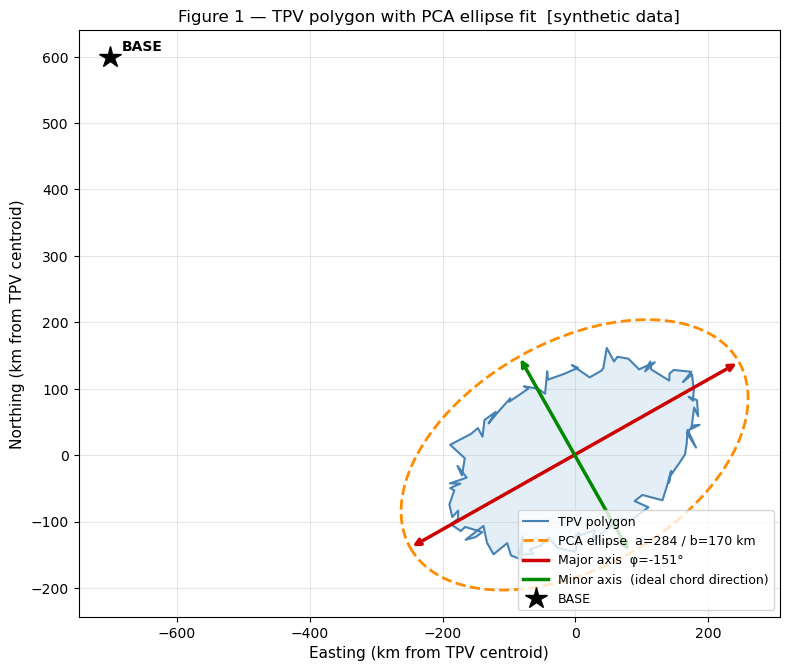

In [4]:
center, a_fit, b_fit, phi_fit = fit_pca_ellipse(TPV_PTS)

# Resolve min chord spacing — auto from PCA or manual override
MIN_LEG_SPACING_KM = SPACING_OVERRIDE_KM if SPACING_OVERRIDE_KM is not None else b_fit
print(f'Min chord spacing : {MIN_LEG_SPACING_KM:.0f} km  '
      f'({"manual override" if SPACING_OVERRIDE_KM is not None else "auto = semi-minor axis b_fit"})')

print(f'PCA fit :  a = {a_fit:.1f} km   b = {b_fit:.1f} km   φ = {degrees(phi_fit):.1f}°')
print(f'True    :  a = {A_TRUE:.1f} km   b = {B_TRUE:.1f} km   φ = {degrees(PHI_TRUE):.1f}°')

major_dir = np.array([cos(phi_fit),          sin(phi_fit)])
minor_dir = np.array([cos(phi_fit + pi/2),   sin(phi_fit + pi/2)])
print(f'Ideal chord direction (minor axis): '
      f'({minor_dir[0]:.3f}, {minor_dir[1]:.3f})')

# Ellipse outline for plotting
R_fit  = rot2d(phi_fit)
th_e   = np.linspace(0, 2*pi, 300)
ell_xy = (R_fit @ np.vstack([a_fit*np.cos(th_e),
                              b_fit*np.sin(th_e)])).T + center

# ── Figure 1: TPV polygon + PCA ellipse ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.55, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5,
        zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=2,
        zorder=3, label=f'PCA ellipse  a={a_fit:.0f} / b={b_fit:.0f} km')

for vec, col, lbl in [
    (major_dir * a_fit, '#cc0000', f'Major axis  φ={degrees(phi_fit):.0f}°'),
    (minor_dir * b_fit, '#008800', 'Minor axis  (ideal chord direction)'),
]:
    ax.annotate('', xy=center+vec, xytext=center-vec,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.5))
    ax.plot([], [], color=col, lw=2.5, label=lbl)

ax.plot(*BASE, '*', color='black', ms=16, zorder=7, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km from TPV centroid)', fontsize=11)
ax.set_ylabel('Northing (km from TPV centroid)', fontsize=11)
ax.set_title('Figure 1 — TPV polygon with PCA ellipse fit  [synthetic data]',
             fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Candidate chord generation and budget feasibility

Chords are generated for `N_ANGLE_SAMPLES` directions spanning ±`MAX_ANGLE_DEV_DEG` around the ideal minor-axis direction.
Along the major axis, positions are spaced `MIN_LEG_SPACING_KM` apart.

**Budget feasibility** (straight-line, no obstacles yet):
```
single_trip = dist(BASE → pt_a) + chord length + dist(pt_b → BASE)
remaining   = TOTAL_BUDGET_KM − single_trip
```
A positive `remaining` means there is budget left for a second transect or satellite coincidence.

In [5]:
angle_devs = np.linspace(-MAX_ANGLE_DEV_DEG, MAX_ANGLE_DEV_DEG,
                          N_ANGLE_SAMPLES).tolist()

chords = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs
)

print(f'Candidate chords: {len(chords)}  '
      f'(angle devs {angle_devs[0]:+.0f}° to {angle_devs[-1]:+.0f}°, '
      f'spacing {MIN_LEG_SPACING_KM:.0f} km)')
print()

# Find best routes for 1, 2, 3 chords
routes = {}
for n in [1, 2, 3]:
    r = best_multi_chord_route(BASE, chords, n)
    routes[n] = r
    if r:
        print(f'{n}-chord route:  TPV dist = {r["tpv_dist"]:.0f} km   '
              f'total dist = {r["total_dist"]:.0f} km   '
              f'turns = {r["n_turns"]}   '
              f'remaining = {r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord route:  no feasible combination found')

Candidate chords: 12  (angle devs -5° to +5°, spacing 100 km)

1-chord route:  TPV dist = 240 km   total dist = 2265 km   turns = 2   remaining = 1985 km
2-chord route:  TPV dist = 462 km   total dist = 2643 km   turns = 4   remaining = 1607 km
3-chord route:  TPV dist = 595 km   total dist = 3264 km   turns = 6   remaining = 986 km


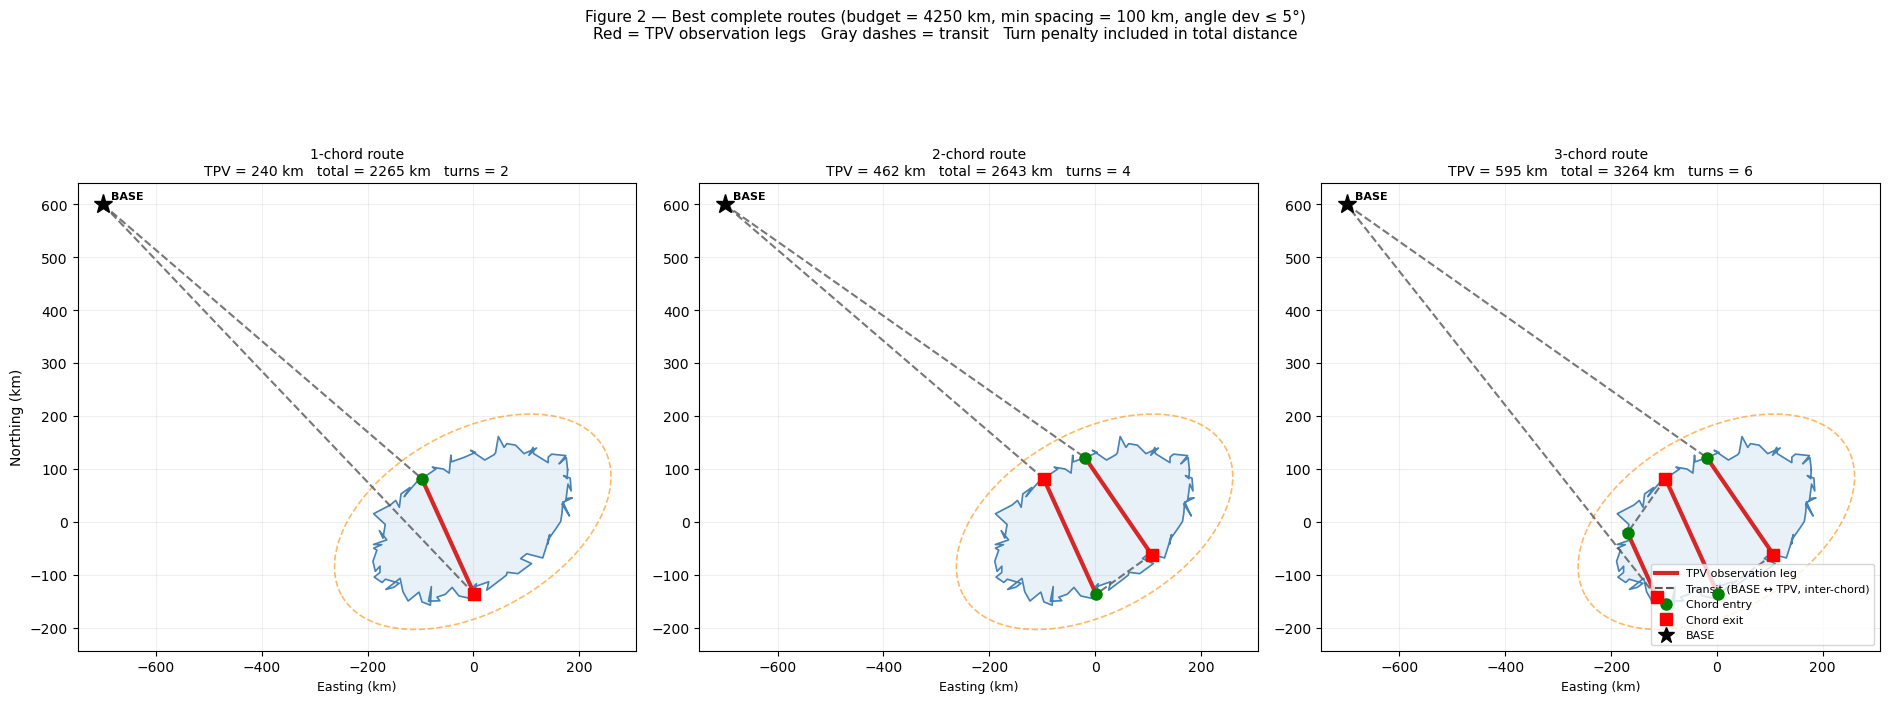

In [6]:
# ── Figure 2: Complete routes for 1, 2, 3 chords ─────────────────────────
def plot_route(ax, route, tpv_pts, ell_xy, base, title):
    """Draw a complete route on ax: transit (dashed gray) + TPV legs (solid blue)."""
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0], closed[:,1], color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0], ell_xy[:,1], '--', color='darkorange',
            lw=1.2, alpha=0.6, zorder=3)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        return

    wpts = route['waypoints']
    segs = route['seg_types']

    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '-', color='#d62728', lw=3, zorder=5, solid_capstyle='round')
        else:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '--', color='#555555', lw=1.5, zorder=4, alpha=0.8)

    # Waypoint markers: entry (circle) and exit (square) for each chord
    tpv_idx = [i for i, s in enumerate(segs) if s == 'tpv']
    for idx in tpv_idx:
        ax.plot(*wpts[idx],   'o', color='green', ms=8, zorder=6)
        ax.plot(*wpts[idx+1], 's', color='red',   ms=8, zorder=6)

    # BASE marker
    ax.plot(*base, '*', color='black', ms=14, zorder=7)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'{title}\n'
        f'TPV = {route["tpv_dist"]:.0f} km   '
        f'total = {route["total_dist"]:.0f} km   '
        f'turns = {route["n_turns"]}',
        fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, n in zip(axes, [1, 2, 3]):
    plot_route(ax, routes[n], TPV_PTS, ell_xy, BASE, f'{n}-chord route')
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#d62728', lw=3,  label='TPV observation leg'),
    Line2D([0], [0], color='#555555', lw=1.5, ls='--', label='Transit (BASE ↔ TPV, inter-chord)'),
    Line2D([0], [0], marker='o', color='green', ms=8, ls='none', label='Chord entry'),
    Line2D([0], [0], marker='s', color='red',   ms=8, ls='none', label='Chord exit'),
    Line2D([0], [0], marker='*', color='black', ms=12, ls='none', label='BASE'),
]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 2 — Best complete routes (budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'min spacing = {MIN_LEG_SPACING_KM:.0f} km, '
    f'angle dev ≤ {MAX_ANGLE_DEV_DEG:.0f}°)\n'
    'Red = TPV observation legs   Gray dashes = transit   '
    'Turn penalty included in total distance',
    fontsize=11)
plt.tight_layout()
plt.show()

---

## Module 2 — Obstacle avoidance & ATC penalty

Two new zone types are loaded here (synthetic polygons — replace with real shapefiles):

| Zone | Effect |
|------|--------|
| **Restricted Airspace** | Hard constraint — route cannot enter |
| **ATC Zone** | Soft penalty — distance inside × `ATC_PENALTY_FACTOR` |

**Approach — Visibility Graph:**
1. Nodes: BASE, all TPV chord endpoints, all polygon vertices (Restricted + ATC)
2. Edges: every pair of nodes whose straight-line segment does not cross any Restricted Airspace polygon
3. Edge cost: straight-line distance × ATC penalty for the fraction inside any ATC Zone
4. Shortest path (Dijkstra) gives the obstacle-avoiding, penalty-weighted transit between any two points

`build_route` is updated to call `obs_dist(p, q)` instead of `straight_dist(p, q)`.

Restricted Airspace polygons : 2
ATC Zone polygons            : 2


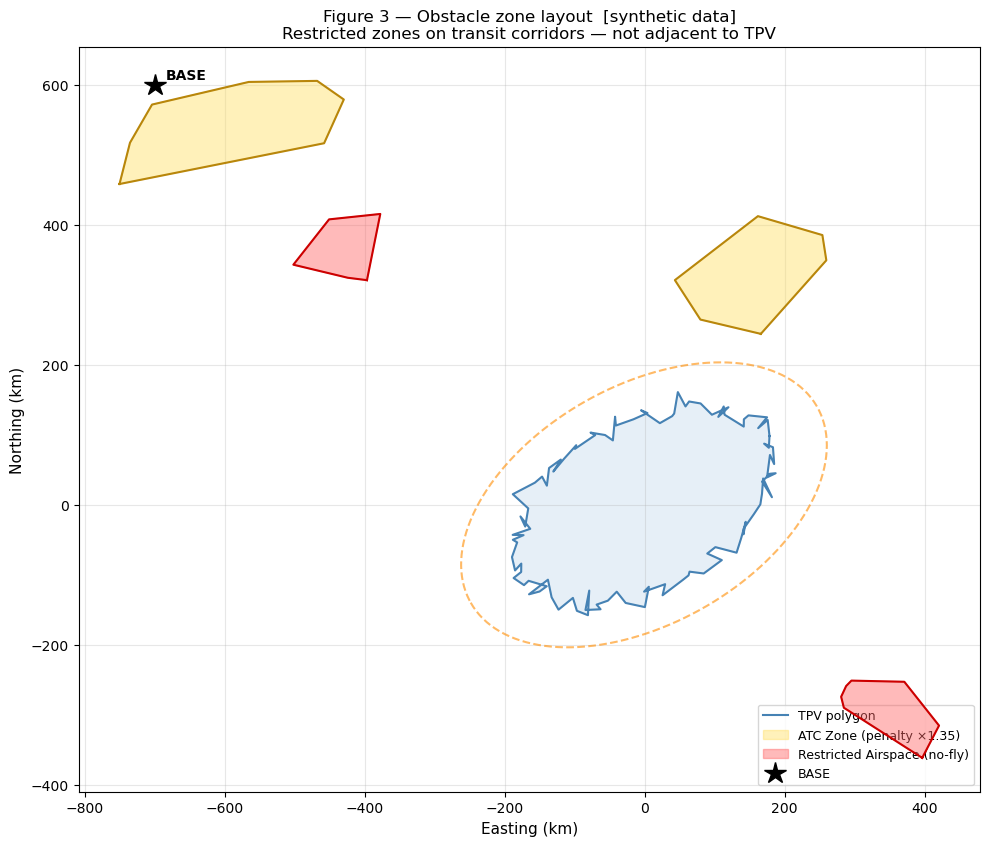

In [7]:
import heapq
from shapely.geometry import MultiPolygon, MultiPoint
from shapely.ops import unary_union

def make_irregular_poly(cx, cy, radius_x, radius_y, n_pts=10, angle_deg=0., seed=0):
    """Irregular convex polygon roughly fitting radius_x × radius_y, rotated by angle_deg."""
    rng = np.random.RandomState(seed)
    raw_angles = np.sort(rng.uniform(0, 2*pi, n_pts))
    r = rng.uniform(0.55, 1.0, n_pts)
    pts = np.column_stack([r * radius_x * np.cos(raw_angles),
                           r * radius_y * np.sin(raw_angles)])
    R = rot2d(radians(angle_deg))
    pts = (R @ pts.T).T + np.array([cx, cy])
    return MultiPoint(pts).convex_hull

# ── Synthetic obstacle zones ──────────────────────────────────────────────
# Restricted Airspace: on the BASE→TPV transit corridor and SE of TPV.
# Both zones are > 400 km from the TPV centroid — well outside the TPV boundary.
restricted_polys = [
    make_irregular_poly(-430,  370,  80,  60, angle_deg= 20., seed=7),  # transit corridor NW
    make_irregular_poly( 350, -300,  90,  65, angle_deg=-15., seed=8),  # SE of TPV
]

# ATC Zones: near BASE and NE of TPV — outside TPV boundary.
atc_polys = [
    make_irregular_poly(-580,  490, 200, 130, angle_deg=10., seed=9),   # near BASE
    make_irregular_poly( 150,  330, 130,  90, angle_deg= 5., seed=10),  # NE of TPV
]

restricted_union = unary_union(restricted_polys)
atc_union        = unary_union(atc_polys)

print(f'Restricted Airspace polygons : {len(restricted_polys)}')
print(f'ATC Zone polygons            : {len(atc_polys)}')

# ── Figure 3: Zone layout ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.5, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5, zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.5, alpha=0.6, zorder=3)

for poly in atc_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ffe066', alpha=0.45, zorder=4)
    ax.plot(xs, ys, color='#b8860b', lw=1.5, zorder=5)
ax.fill([], [], color='#ffe066', alpha=0.45,
        label=f'ATC Zone (penalty ×{ATC_PENALTY_FACTOR})')

for poly in restricted_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ff6666', alpha=0.45, zorder=6)
    ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)
ax.fill([], [], color='#ff6666', alpha=0.45, label='Restricted Airspace (no-fly)')

ax.plot(*BASE, '*', color='black', ms=16, zorder=10, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points', xytext=(8, 4),
            fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km)', fontsize=11)
ax.set_ylabel('Northing (km)', fontsize=11)
ax.set_title('Figure 3 — Obstacle zone layout  [synthetic data]\n'
             'Restricted zones on transit corridors — not adjacent to TPV', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ── Re-generate candidate chords filtered against restricted airspace ─────
# Chords whose segments enter any restricted polygon are discarded here,
# so the observation legs themselves never cross a no-fly zone.
chords_obs = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs,
    restricted_geom=restricted_union,
)
print(f'Candidate chords: {len(chords)} total → {len(chords_obs)} after restricted-airspace filter')

# ── Visibility graph construction ─────────────────────────────────────────

def build_visibility_graph(nodes, restricted, atc):
    """Build a weighted visibility graph over a list of (x,y) nodes.

    Edges connect every pair of nodes whose segment does not cross restricted airspace.
    Edge weight = effective distance (ATC penalty applied to in-zone portions).

    Returns: adj — dict mapping node_index → list of (neighbour_index, cost).
    """
    n = len(nodes)
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            p1, p2 = nodes[i], nodes[j]
            if seg_crosses_restricted(p1, p2, restricted):
                continue
            cost = seg_atc_cost(p1, p2, atc)
            adj[i].append((j, cost))
            adj[j].append((i, cost))
    return adj

def dijkstra(adj, src, dst):
    """Shortest path from src to dst index in adjacency dict.
    Returns (cost, path_indices) or (inf, []) if unreachable.
    """
    dist = {src: 0.0}
    prev = {src: None}
    heap = [(0.0, src)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist.get(u, float('inf')):
            continue
        if u == dst:
            break
        for v, w in adj[u]:
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                prev[v] = u
                heapq.heappush(heap, (nd, v))
    if dst not in dist:
        return float('inf'), []
    path, cur = [], dst
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    return dist[dst], list(reversed(path))


def polygon_vertices(polys):
    verts = []
    for poly in polys:
        coords = list(poly.exterior.coords)[:-1]
        verts.extend(coords)
    return [np.array(v) for v in verts]

# Graph nodes: BASE + filtered chord endpoints + polygon vertices
chord_endpoints = []
for c in chords_obs:
    chord_endpoints.extend([c['pt_a'], c['pt_b']])

all_nodes = (
    [BASE]
    + chord_endpoints
    + polygon_vertices(restricted_polys)
    + polygon_vertices(atc_polys)
)
all_nodes = [np.asarray(n, float) for n in all_nodes]

BASE_IDX = 0
chord_node_idx = {}
for k, c in enumerate(chords_obs):
    base_off = 1 + 2 * k
    chord_node_idx[(k, 'a')] = base_off
    chord_node_idx[(k, 'b')] = base_off + 1

print(f'Visibility graph: {len(all_nodes)} nodes')
print('Building edges (checking restricted airspace crossings)...')

adj = build_visibility_graph(all_nodes, restricted_union, atc_union)

n_edges = sum(len(v) for v in adj.values()) // 2
print(f'Done: {n_edges} valid edges')

Candidate chords: 12 total → 12 after restricted-airspace filter
Visibility graph: 50 nodes
Building edges (checking restricted airspace crossings)...
Done: 962 valid edges


In [9]:
# ── Obstacle-aware transit and updated route builder ──────────────────────

def node_idx(pt):
    """Find the index of pt in all_nodes (exact match)."""
    for i, n in enumerate(all_nodes):
        if np.allclose(n, pt, atol=1e-6):
            return i
    return None

def obs_transit(p, q):
    """Obstacle-avoiding effective distance from p to q via Dijkstra on visibility graph.
    Returns (cost, waypoint_array).
    """
    i, j = node_idx(p), node_idx(q)
    if i is None or j is None:
        return float('inf'), np.array([p, q])
    cost, path_idx = dijkstra(adj, i, j)
    wpts = np.array([all_nodes[k] for k in path_idx])
    return cost, wpts


def build_route_obs(base, ordered_chords):
    """Complete route with obstacle-aware transits.

    Transit segments are routed via the visibility graph (avoiding restricted airspace,
    penalising ATC zones). Turn penalty is computed once across the full waypoint
    sequence using count_turns_in_path — counting every direction change ≥
    TURN_THRESHOLD_DEG, including visibility-graph detour bends.
    """
    pos  = np.asarray(base, float)
    wpts = [pos.copy()]
    segs = []
    total_dist = tpv_dist = 0.0

    for c in ordered_chords:
        pt_a = np.asarray(c['pt_a'], float)
        pt_b = np.asarray(c['pt_b'], float)

        # Choose entry endpoint with cheaper obstacle-aware transit
        cost_a, wpts_a = obs_transit(pos, pt_a)
        cost_b, wpts_b = obs_transit(pos, pt_b)

        if cost_a <= cost_b:
            entry, exit_, transit_cost, transit_wpts = pt_a, pt_b, cost_a, wpts_a
        else:
            entry, exit_, transit_cost, transit_wpts = pt_b, pt_a, cost_b, wpts_b

        if transit_cost == float('inf'):
            return None   # no valid path to this chord

        # Transit to chord entry (intermediate obstacle-detour waypoints included)
        total_dist += transit_cost
        for wp in transit_wpts[1:]:    # transit_wpts[0] == pos, already in wpts
            wpts.append(wp)
            segs.append('transit')

        # Chord observation leg inside TPV
        total_dist += c['length']
        tpv_dist   += c['length']
        wpts.append(exit_)
        segs.append('tpv')

        pos = exit_

    # Return to BASE
    return_cost, return_wpts = obs_transit(pos, base)
    if return_cost == float('inf'):
        return None
    total_dist += return_cost
    for wp in return_wpts[1:]:
        wpts.append(wp)
        segs.append('transit')

    # Count ALL direction changes across the full waypoint sequence
    n_turns     = count_turns_in_path(wpts)
    total_dist += n_turns * TURN_PENALTY_KM

    return dict(
        waypoints=np.array(wpts),
        seg_types=segs,
        total_dist=total_dist,
        tpv_dist=tpv_dist,
        n_turns=n_turns,
        feasible=total_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - total_dist,
    )


def best_multi_chord_route_obs(base, chords, n_chords,
                                min_spacing=MIN_LEG_SPACING_KM):
    """Like best_multi_chord_route but uses obstacle-aware transits."""
    best = None
    best_tpv = -1.0
    for combo in combinations(chords, n_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_chords > 1 and any(
            offsets[i+1] - offsets[i] < min_spacing
            for i in range(n_chords - 1)
        ):
            continue
        for ordered in [
            sorted(combo, key=lambda c:  c['offset']),
            sorted(combo, key=lambda c: -c['offset']),
        ]:
            route = build_route_obs(base, ordered)
            if route and route['feasible'] and route['tpv_dist'] > best_tpv:
                best_tpv = route['tpv_dist']
                best = route
    return best


print('Obstacle-aware route builder ready.')

# Find best routes with obstacle avoidance (using filtered chords_obs)
routes_obs = {}
for n in [1, 2, 3]:
    r = best_multi_chord_route_obs(BASE, chords_obs, n)
    routes_obs[n] = r
    if r:
        print(f'{n}-chord (obs): TPV = {r["tpv_dist"]:.0f} km   '
              f'total = {r["total_dist"]:.0f} km   '
              f'turns = {r["n_turns"]}   '
              f'remaining = {r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord (obs): no feasible route found')

Obstacle-aware route builder ready.
1-chord (obs): TPV = 240 km   total = 2465 km   turns = 3   remaining = 1785 km


2-chord (obs): TPV = 462 km   total = 2858 km   turns = 5   remaining = 1392 km


3-chord (obs): TPV = 595 km   total = 3362 km   turns = 6   remaining = 888 km


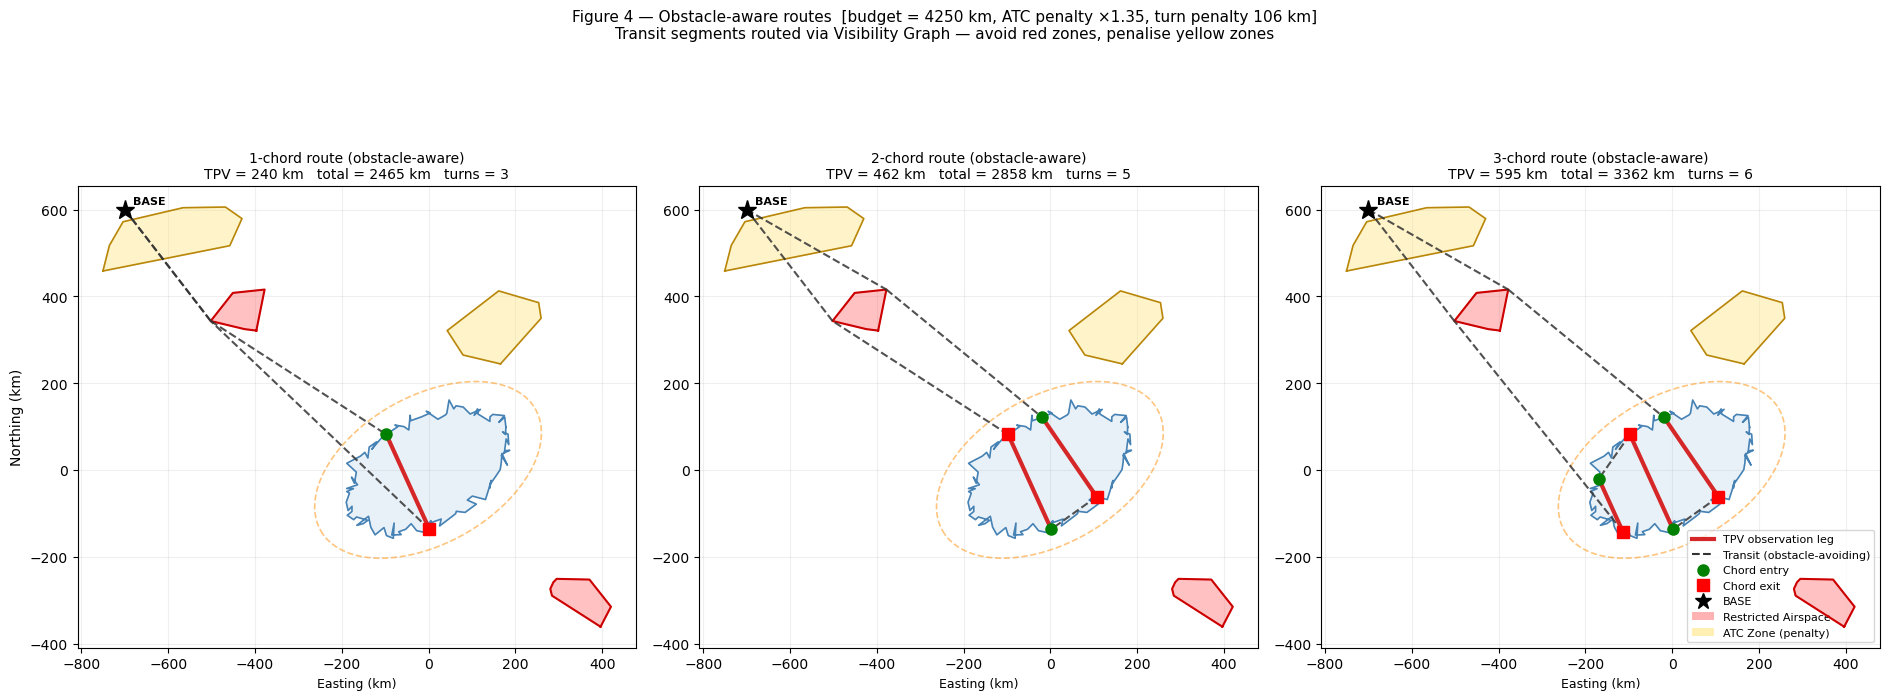

In [10]:
# ── Figure 4: Complete obstacle-aware routes ──────────────────────────────
def plot_route_obs(ax, route, tpv_pts, ell_xy, base,
                   restricted_polys, atc_polys, title):
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.2, alpha=0.5, zorder=3)

    for poly in atc_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ffe066', alpha=0.35, zorder=4)
        ax.plot(xs, ys, color='#b8860b', lw=1.2, zorder=5)

    for poly in restricted_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ff6666', alpha=0.40, zorder=6)
        ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
        return

    wpts = route['waypoints']
    segs = route['seg_types']

    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '-', color='#d62728', lw=3, zorder=9, solid_capstyle='round')
        else:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '--', color='#333333', lw=1.5, zorder=8, alpha=0.85)

    tpv_idx = [i for i, s in enumerate(segs) if s == 'tpv']
    for idx in tpv_idx:
        ax.plot(*wpts[idx],   'o', color='green', ms=8, zorder=10)
        ax.plot(*wpts[idx+1], 's', color='red',   ms=8, zorder=10)

    ax.plot(*base, '*', color='black', ms=14, zorder=11)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'{title}\n'
        f'TPV = {route["tpv_dist"]:.0f} km   '
        f'total = {route["total_dist"]:.0f} km   '
        f'turns = {route["n_turns"]}',
        fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, n in zip(axes, [1, 2, 3]):
    plot_route_obs(ax, routes_obs[n], TPV_PTS, ell_xy, BASE,
                   restricted_polys, atc_polys, f'{n}-chord route (obstacle-aware)')
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0],[0], color='#d62728', lw=3,             label='TPV observation leg'),
    Line2D([0],[0], color='#333333', lw=1.5, ls='--',  label='Transit (obstacle-avoiding)'),
    Line2D([0],[0], marker='o', color='green', ms=8, ls='none', label='Chord entry'),
    Line2D([0],[0], marker='s', color='red',   ms=8, ls='none', label='Chord exit'),
    Line2D([0],[0], marker='*', color='black', ms=12, ls='none', label='BASE'),
    Patch(facecolor='#ff6666', alpha=0.5, label='Restricted Airspace'),
    Patch(facecolor='#ffe066', alpha=0.5, label='ATC Zone (penalty)'),
]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 4 — Obstacle-aware routes  [budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'ATC penalty ×{ATC_PENALTY_FACTOR}, turn penalty {TURN_PENALTY_KM:.0f} km]\n'
    'Transit segments routed via Visibility Graph — avoid red zones, penalise yellow zones',
    fontsize=11)
plt.tight_layout()
plt.show()

---

## Module 3 — Satellite coincidence segment

The aircraft should fly along the **EarthCARE ground track** for at least `T_MIN_SAT_MIN` minutes to enable coincident remote-sensing measurements. This is a secondary objective (TPV transects take priority).

| Variable | Meaning |
|----------|---------|
| `SAT_DIR` | Unit vector along satellite travel direction |
| `SAT_REF_PT` | Reference point on the ground track (inside or near TPV) |
| `T_SAT_H` | Time at which the satellite passes `SAT_REF_PT` (hours after departure) |
| `SAT_MIN_LENGTH_KM` | Minimum coincidence length = `T_MIN_SAT_MIN / 60 × speed` ≈ 142 km |

**Approach:**
1. Clip the satellite ground track against restricted airspace; take the longest valid sub-segment ≥ `SAT_MIN_LENGTH_KM`
2. Add the satellite segment endpoints to the visibility graph
3. Enumerate route orderings: satellite-first or satellite-last relative to the TPV chords
4. Back-calculate departure time: `T_dep = T_sat − d(BASE → sat midpoint) / speed`

**Why geometric distance for timing?** The ATC penalty represents increased fuel burn at low altitude, not extra flight time. Turns add time (`TURN_PENALTY_MIN` min each). Both corrections are applied to effective distance (budget), but actual clock time uses only the geometric path length.

In [11]:
import time

# ── Module 3 parameters ───────────────────────────────────────────────────
SAT_MIN_LENGTH_KM = T_MIN_SAT_MIN / 60.0 * AIRCRAFT_SPEED_KMH  # ≈ 142 km
SAT_TRACK_KM      = 1000.0   # total track length for visualisation
SAT_SAMPLE_KM     = 200.0    # sampling interval → candidate entry/exit points
MAX_JOINT_N       = 5        # max chords tried in joint search

T_SAT_H = 2.0   # satellite passes reference point at t = 2 h after departure

print(f'Min satellite coincidence : {SAT_MIN_LENGTH_KM:.0f} km  ({T_MIN_SAT_MIN:.0f} min)')
print(f'Track                     : {SAT_TRACK_KM:.0f} km sampled every {SAT_SAMPLE_KM:.0f} km')

# ── Four EarthCARE track examples ─────────────────────────────────────────
sat_track_defs = [
    dict(label='Track A (through TPV)',   ref_offset=np.array([ 20., -40.]),  angle_offset_deg= 55.),
    dict(label='Track B (NW, above TPV)', ref_offset=np.array([-160., 230.]),  angle_offset_deg= 18.),
    dict(label='Track C (SE, steep)',     ref_offset=np.array([ 190.,-110.]),  angle_offset_deg=-38.),
    dict(label='Track D (S, below TPV)', ref_offset=np.array([ -50.,-230.]),  angle_offset_deg= 72.),
]

half_track = SAT_TRACK_KM / 2.0
for tr in sat_track_defs:
    phi    = phi_fit + radians(tr['angle_offset_deg'])
    d      = np.array([cos(phi), sin(phi)])
    ref    = np.asarray(center) + tr['ref_offset']
    t_vals = np.arange(-half_track, half_track + 1e-6, SAT_SAMPLE_KM)
    pts    = [np.asarray(ref + t * d) for t in t_vals]
    cands  = [
        (pts[i], pts[j], float(np.linalg.norm(pts[j] - pts[i])))
        for i in range(len(pts))
        for j in range(i + 1, len(pts))
        if np.linalg.norm(pts[j] - pts[i]) >= SAT_MIN_LENGTH_KM
        and not seg_crosses_restricted(pts[i], pts[j], restricted_union)
    ]
    tr.update(phi=phi, dir=d, ref=ref,
              line=LineString([ref - half_track * d, ref + half_track * d]),
              sample_pts=pts, candidates=cands)
    print(f"  {tr['label']}: {len(pts)} pts → {len(cands)} valid (entry,exit) pairs")

# ── Extended visibility graph (all 4 tracks' sample points) ───────────────
all_sat_pts = []
for tr in sat_track_defs:
    for pt in tr['sample_pts']:
        if not any(np.allclose(pt, ep, atol=0.1) for ep in all_sat_pts):
            all_sat_pts.append(pt)

all_nodes_m3 = all_nodes + all_sat_pts
print(f'\nBuilding extended vis-graph ({len(all_nodes_m3)} nodes)...')
t0 = time.time()
adj_m3 = build_visibility_graph(all_nodes_m3, restricted_union, atc_union)
print(f'Vis-graph: {sum(len(v) for v in adj_m3.values())//2} edges  [{time.time()-t0:.1f}s]')

# ── Precompute all-pairs shortest paths ───────────────────────────────────
# Running Dijkstra once per source node (N_M3 total) and caching the results
# makes each route evaluation O(path_len) instead of O(Dijkstra).
# Speedup: ~1 000x over calling Dijkstra inside the search loop.
N_M3      = len(all_nodes_m3)
_eff_cost = [dict() for _ in range(N_M3)]   # _eff_cost[src][dst]
_prev     = [dict() for _ in range(N_M3)]   # prev node in shortest path from src

t0 = time.time()
for src in range(N_M3):
    _eff_cost[src][src] = 0.0
    _prev[src][src]     = None
    heap = [(0.0, src)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > _eff_cost[src].get(u, 1e18):
            continue
        for v, w in adj_m3[u]:
            nd = d + w
            if nd < _eff_cost[src].get(v, 1e18):
                _eff_cost[src][v] = nd
                _prev[src][v]     = u
                heapq.heappush(heap, (nd, v))
print(f'All-pairs SP precomputed   [{time.time()-t0:.2f}s]')

# O(1) node lookup via rounded-tuple hash
_node_key = {tuple(np.round(n, 3)): i for i, n in enumerate(all_nodes_m3)}

def node_idx_m3(pt):
    return _node_key.get(tuple(np.round(pt, 3)), None)

def obs_transit_m3_fast(p, q):
    """O(path_len) obstacle-avoiding transit using precomputed SP."""
    i, j = node_idx_m3(p), node_idx_m3(q)
    if i is None or j is None:
        return float('inf'), np.array([p, q])
    cost = _eff_cost[i].get(j, float('inf'))
    if cost == float('inf'):
        return float('inf'), np.array([p, q])
    # Reconstruct path i → j
    path, cur = [], j
    while cur is not None:
        path.append(cur); cur = _prev[i].get(cur)
    path.reverse()
    return cost, np.array([all_nodes_m3[k] for k in path])


# ── Route builder with flexible satellite segment ─────────────────────────
def build_route_m3_flex(base, ordered_chords, sat_a, sat_b, sat_len,
                         T_sat_h, sat_first=False):
    """Complete route: TPV chords + satellite coincidence.
    sat_a, sat_b: chosen entry/exit on the track (optimizer's decision).
    T_dep back-calculated so aircraft reaches sat midpoint exactly at T_sat_h.
    """
    tpv_legs = [('tpv', c['pt_a'], c['pt_b'], c['length']) for c in ordered_chords]
    sat_leg  = [('sat', np.asarray(sat_a), np.asarray(sat_b), sat_len)]
    legs     = sat_leg + tpv_legs if sat_first else tpv_legs + sat_leg

    pos  = np.asarray(base, float)
    wpts = [pos.copy()]; segs = []
    eff_dist = geo_dist = tpv_dist = sat_dist_flew = 0.0
    geo_to_sat_mid = None

    for leg_type, pt_a, pt_b, length in legs:
        pt_a, pt_b = np.asarray(pt_a, float), np.asarray(pt_b, float)
        cost_a, wpts_a = obs_transit_m3_fast(pos, pt_a)
        cost_b, wpts_b = obs_transit_m3_fast(pos, pt_b)
        if cost_a <= cost_b:
            entry, exit_, eff_t, t_wpts = pt_a, pt_b, cost_a, wpts_a
        else:
            entry, exit_, eff_t, t_wpts = pt_b, pt_a, cost_b, wpts_b
        if eff_t == float('inf'):
            return None
        geo_t = sum(float(np.linalg.norm(t_wpts[k+1] - t_wpts[k]))
                    for k in range(len(t_wpts) - 1))
        eff_dist += eff_t;  geo_dist += geo_t
        for wp in t_wpts[1:]:
            wpts.append(wp); segs.append('transit')
        if leg_type == 'sat':
            geo_to_sat_mid = geo_dist + length / 2.0
            sat_dist_flew  = length
        else:
            tpv_dist += length
        eff_dist += length; geo_dist += length
        wpts.append(exit_); segs.append(leg_type)
        pos = exit_

    ret_cost, ret_wpts = obs_transit_m3_fast(pos, base)
    if ret_cost == float('inf'):
        return None
    ret_geo = sum(float(np.linalg.norm(ret_wpts[k+1] - ret_wpts[k]))
                  for k in range(len(ret_wpts) - 1))
    eff_dist += ret_cost; geo_dist += ret_geo
    for wp in ret_wpts[1:]:
        wpts.append(wp); segs.append('transit')

    n_turns   = count_turns_in_path(wpts)
    eff_dist += n_turns * TURN_PENALTY_KM
    T_dep_h   = T_sat_h - geo_to_sat_mid / AIRCRAFT_SPEED_KMH

    return dict(
        waypoints=np.array(wpts), seg_types=segs,
        total_dist=eff_dist, tpv_dist=tpv_dist, sat_dist=sat_dist_flew,
        n_turns=n_turns, feasible=eff_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - eff_dist, T_dep_h=T_dep_h,
    )


def find_best_for_track(base, chords, sat_candidates, T_sat_h,
                         min_spacing=MIN_LEG_SPACING_KM):
    """Joint search: max feasible chord count + best satellite segment.
    Tries n from MAX_JOINT_N down; returns as soon as a feasible n is found.
    """
    best = None; best_tpv = -1.0; best_n = 0
    for n in range(min(len(chords), MAX_JOINT_N), 0, -1):
        found = False
        for combo in combinations(chords, n):
            offsets = sorted(c['offset'] for c in combo)
            if n > 1 and any(offsets[i+1] - offsets[i] < min_spacing
                             for i in range(n - 1)):
                continue
            for ordered in [sorted(combo, key=lambda c:  c['offset']),
                            sorted(combo, key=lambda c: -c['offset'])]:
                for sa, sb, sl in sat_candidates:
                    for sat_first in [False, True]:
                        r = build_route_m3_flex(base, ordered, sa, sb, sl,
                                                T_sat_h, sat_first)
                        if r and r['feasible'] and r['tpv_dist'] > best_tpv:
                            best_tpv = r['tpv_dist']
                            best = r; best_n = n; found = True
        if found:
            return best, best_n
    return None, 0


# ── Solve for all four tracks ─────────────────────────────────────────────
print()
track_results = {}
for tr in sat_track_defs:
    t0 = time.time()
    r, n = find_best_for_track(BASE, chords_obs, tr['candidates'], T_SAT_H)
    elapsed = time.time() - t0
    track_results[tr['label']] = {'route': r, 'n_chords': n, 'track': tr}
    if r:
        offset = r['T_dep_h'] - T_SAT_H
        sign   = '+' if offset >= 0 else ''
        print(f"{tr['label']}: n={n}  TPV={r['tpv_dist']:.0f} km  "
              f"sat={r['sat_dist']:.0f} km  total={r['total_dist']:.0f} km  "
              f"turns={r['n_turns']}  T_dep=T_sat{sign}{offset:.2f}h  [{elapsed:.1f}s]")
    else:
        print(f"{tr['label']}: no feasible route  [{elapsed:.1f}s]")

Min satellite coincidence : 142 km  (10 min)
Track                     : 1000 km sampled every 200 km
  Track A (through TPV): 6 pts → 15 valid (entry,exit) pairs
  Track B (NW, above TPV): 6 pts → 15 valid (entry,exit) pairs
  Track C (SE, steep): 6 pts → 15 valid (entry,exit) pairs
  Track D (S, below TPV): 6 pts → 15 valid (entry,exit) pairs

Building extended vis-graph (74 nodes)...


Vis-graph: 2283 edges  [0.2s]
All-pairs SP precomputed   [0.08s]



Track A (through TPV): n=4  TPV=716 km  sat=200 km  total=4110 km  turns=10  T_dep=T_sat-1.04h  [3.1s]


Track B (NW, above TPV): n=4  TPV=716 km  sat=200 km  total=4210 km  turns=10  T_dep=T_sat-0.91h  [2.5s]


Track C (SE, steep): n=4  TPV=716 km  sat=200 km  total=4143 km  turns=10  T_dep=T_sat-2.52h  [2.5s]


Track D (S, below TPV): n=4  TPV=716 km  sat=200 km  total=4085 km  turns=10  T_dep=T_sat-2.55h  [2.3s]


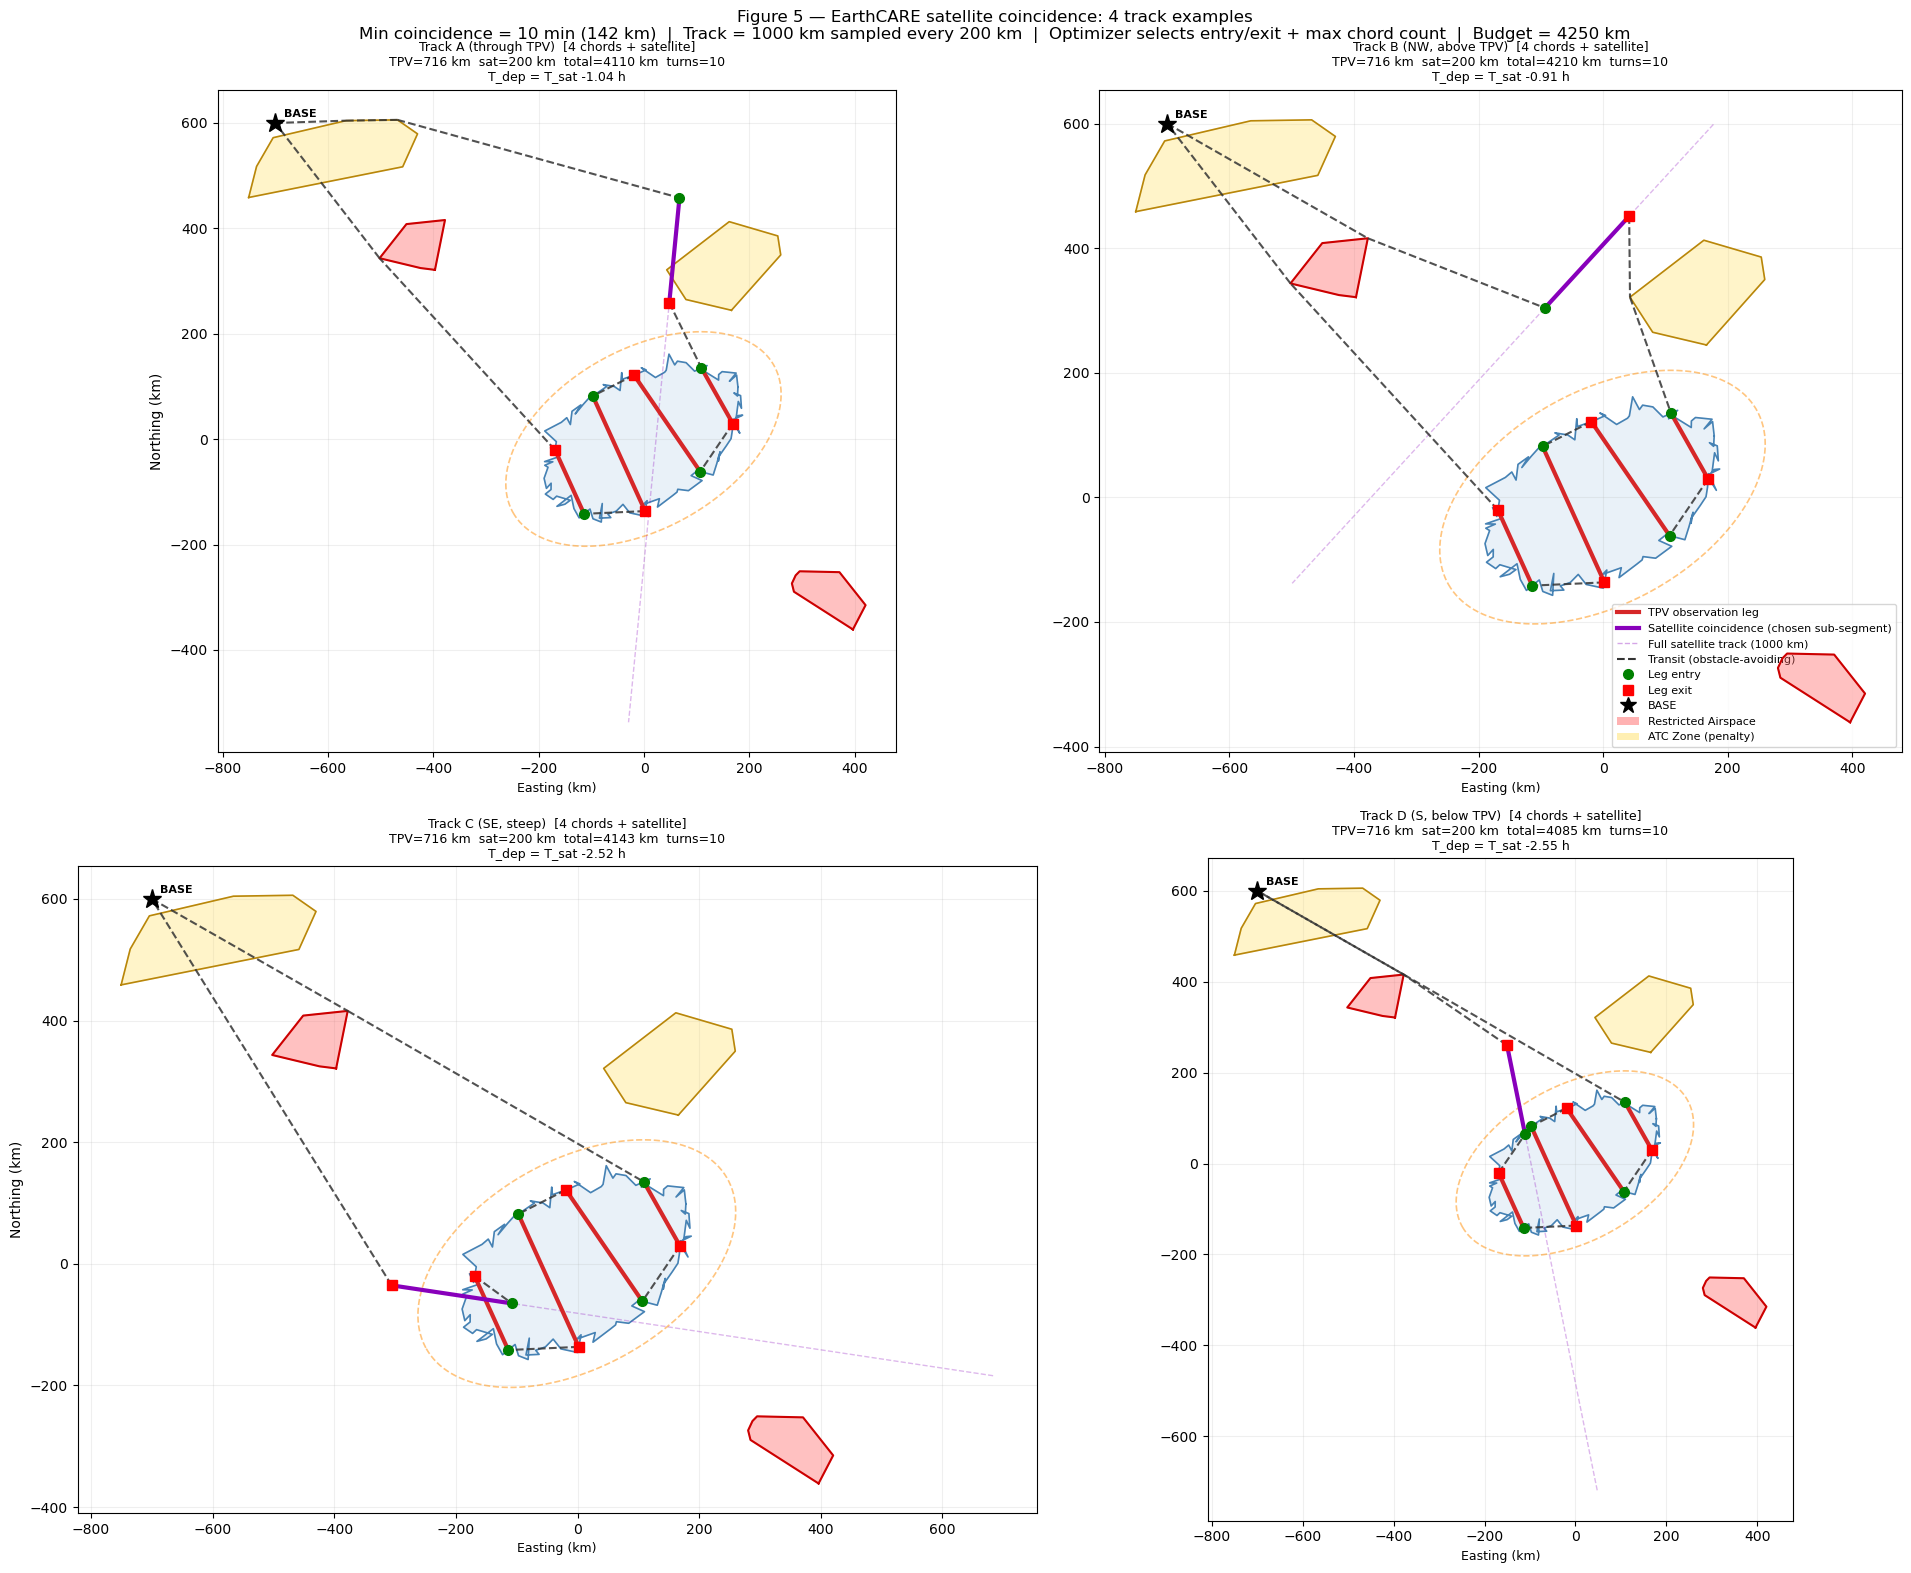

In [12]:
# ── Figure 5: 2×2 comparison — one panel per EarthCARE track ──────────────
def plot_route_m3(ax, route, tpv_pts, ell_xy, base,
                  restricted_polys, atc_polys, sat_line, title):
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.2, alpha=0.5, zorder=3)

    # Full satellite ground track (faint dashed reference)
    sat_c = np.array(sat_line.coords)
    ax.plot(sat_c[:,0], sat_c[:,1], '--', color='#8800bb', lw=1.0, alpha=0.28, zorder=4)

    for poly in atc_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ffe066', alpha=0.35, zorder=4)
        ax.plot(xs, ys, color='#b8860b', lw=1.2, zorder=5)
    for poly in restricted_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ff6666', alpha=0.40, zorder=6)
        ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2); return

    wpts = route['waypoints']
    segs = route['seg_types']
    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color='#d62728',
                    lw=3, zorder=9, solid_capstyle='round')
        elif seg_type == 'sat':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color='#8800bb',
                    lw=3, zorder=9, solid_capstyle='round')
        else:
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '--', color='#333333',
                    lw=1.5, zorder=8, alpha=0.85)

    for i, s in enumerate(segs):
        if s in ('tpv', 'sat'):
            ax.plot(*wpts[i],   'o', color='green', ms=7, zorder=10)
            ax.plot(*wpts[i+1], 's', color='red',   ms=7, zorder=10)

    ax.plot(*base, '*', color='black', ms=14, zorder=11)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    offset = route['T_dep_h'] - T_SAT_H
    sign   = '+' if offset >= 0 else ''
    ax.set_title(
        f'{title}\n'
        f'TPV={route["tpv_dist"]:.0f} km  sat={route["sat_dist"]:.0f} km  '
        f'total={route["total_dist"]:.0f} km  turns={route["n_turns"]}\n'
        f'T_dep = T_sat {sign}{offset:.2f} h',
        fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for ax, (lbl, res) in zip(axes, track_results.items()):
    tr      = res['track']
    route   = res['route']
    n_chord = res['n_chords']
    panel_title = f"{lbl}  [{n_chord} chord{'s' if n_chord != 1 else ''} + satellite]"
    plot_route_m3(ax, route, TPV_PTS, ell_xy, BASE,
                  restricted_polys, atc_polys, tr['line'], panel_title)
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)
axes[2].set_ylabel('Northing (km)', fontsize=10)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0],[0], color='#d62728', lw=3,              label='TPV observation leg'),
    Line2D([0],[0], color='#8800bb', lw=3,              label='Satellite coincidence (chosen sub-segment)'),
    Line2D([0],[0], color='#8800bb', lw=1, ls='--', alpha=0.35, label='Full satellite track (1000 km)'),
    Line2D([0],[0], color='#333333', lw=1.5, ls='--',   label='Transit (obstacle-avoiding)'),
    Line2D([0],[0], marker='o', color='green', ms=7, ls='none', label='Leg entry'),
    Line2D([0],[0], marker='s', color='red',   ms=7, ls='none', label='Leg exit'),
    Line2D([0],[0], marker='*', color='black', ms=12, ls='none', label='BASE'),
    Patch(facecolor='#ff6666', alpha=0.5, label='Restricted Airspace'),
    Patch(facecolor='#ffe066', alpha=0.5, label='ATC Zone (penalty)'),
]
axes[1].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 5 — EarthCARE satellite coincidence: 4 track examples\n'
    f'Min coincidence = {T_MIN_SAT_MIN:.0f} min ({SAT_MIN_LENGTH_KM:.0f} km)  |  '
    f'Track = {SAT_TRACK_KM:.0f} km sampled every {SAT_SAMPLE_KM:.0f} km  |  '
    f'Optimizer selects entry/exit + max chord count  |  Budget = {TOTAL_BUDGET_KM:.0f} km',
    fontsize=12)
plt.tight_layout()
plt.show()

---

## Module 3b — Multiple coincidence opportunities (2000 km tracks)

Three long coincidence tracks (2000 km each) are available simultaneously.
Each track could be a **satellite ground track** or **another aircraft's flight path**
(for inter-instrument cross-calibration).

The optimizer jointly selects:
1. **Which track** to fly coincident with
2. **Which sub-segment** of that track (entry/exit points as decision variables)
3. **How many TPV chords** to fit within the remaining budget

A 2000 km track is much longer than the minimum coincidence segment (≈142 km),
so the optimizer must choose the most convenient sub-segment — the one that minimises
detour while maximising TPV coverage.

In [13]:
# ── Module 3b parameters ──────────────────────────────────────────────────
SAT_TRACK_KM_B  = 2000.0   # total track length (much longer than min coincidence)
ENTRY_STEP_KM   =   50.0   # entry every 50 km → near-continuous coverage
COINC_KM        = SAT_MIN_LENGTH_KM   # fixed coincidence segment length ≈ 142 km
MAX_JOINT_N_B   =    4     # cap: n=5 + any satellite exceeds budget

half_b = SAT_TRACK_KM_B / 2.0
print(f'Track length  : {SAT_TRACK_KM_B:.0f} km  (entry every {ENTRY_STEP_KM:.0f} km)')
print(f'Coincidence   : {COINC_KM:.1f} km  fixed segment  →  optimizer selects entry position')

# ── Three coincidence track definitions ───────────────────────────────────
# Each could be a satellite overpass or another research aircraft's flight path.
coinc_track_defs = [
    dict(label='Track P1 (through TPV, 50°)',
         ref_offset=np.array([  0.,   0.]),  angle_offset_deg= 50.),
    dict(label='Track P2 (NW corridor, 12°)',
         ref_offset=np.array([-200., 280.]), angle_offset_deg= 12.),
    dict(label='Track P3 (SE diagonal, -45°)',
         ref_offset=np.array([ 180.,-130.]), angle_offset_deg=-45.),
]
TRACK_COLORS = ['#2ca02c', '#1f77b4', '#ff7f0e']   # green, blue, orange

for tr in coinc_track_defs:
    phi    = phi_fit + radians(tr['angle_offset_deg'])
    d      = np.array([cos(phi), sin(phi)])
    ref    = np.asarray(center) + tr['ref_offset']
    # Entry positions every ENTRY_STEP_KM; exit = entry + COINC_KM along track
    t_entries = np.arange(-half_b, half_b - COINC_KM + 1e-6, ENTRY_STEP_KM)
    cands = []
    graph_pts = []   # both entry and exit added as vis-graph nodes
    for t_e in t_entries:
        pa = np.asarray(ref + t_e * d)
        pb = np.asarray(ref + (t_e + COINC_KM) * d)
        if not seg_crosses_restricted(pa, pb, restricted_union):
            cands.append((pa, pb, COINC_KM))
            graph_pts.append(pa)
            graph_pts.append(pb)
    # Deduplicate graph points
    unique_gpts = []
    for pt in graph_pts:
        if not any(np.allclose(pt, ep, atol=0.1) for ep in unique_gpts):
            unique_gpts.append(pt)
    tr.update(phi=phi, dir=d, ref=ref,
              line=LineString([ref - half_b * d, ref + half_b * d]),
              sample_pts=unique_gpts, candidates=cands)
    print(f"  {tr['label']}: {len(t_entries)} entry positions → {len(cands)} valid pairs"
          f"  ({len(unique_gpts)} graph nodes)")

# Flatten all candidates, tagging each with its track index
combined_cands_b = [
    (sa, sb, sl, tr_idx)
    for tr_idx, tr in enumerate(coinc_track_defs)
    for sa, sb, sl in tr['candidates']
]
print(f"\n  Combined pool: {len(combined_cands_b)} (entry,exit,track) candidates")

# ── Visibility graph for Module 3b ────────────────────────────────────────
# Fresh graph: existing nodes + all 3 tracks' entry/exit points.
all_coinc_pts = []
for tr in coinc_track_defs:
    for pt in tr['sample_pts']:
        if not any(np.allclose(pt, ep, atol=0.1) for ep in all_coinc_pts):
            all_coinc_pts.append(pt)

all_nodes_b = all_nodes + all_coinc_pts
print(f'\nBuilding vis-graph ({len(all_nodes_b)} nodes)...')
t0 = time.time()
adj_b = build_visibility_graph(all_nodes_b, restricted_union, atc_union)
print(f'Vis-graph: {sum(len(v) for v in adj_b.values())//2} edges  [{time.time()-t0:.1f}s]')

# Precompute all-pairs shortest paths
N_B      = len(all_nodes_b)
_eff_b   = [dict() for _ in range(N_B)]
_prev_b  = [dict() for _ in range(N_B)]
t0 = time.time()
for src in range(N_B):
    _eff_b[src][src]  = 0.0
    _prev_b[src][src] = None
    heap = [(0.0, src)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > _eff_b[src].get(u, 1e18):
            continue
        for v, w in adj_b[u]:
            nd = d + w
            if nd < _eff_b[src].get(v, 1e18):
                _eff_b[src][v] = nd
                _prev_b[src][v] = u
                heapq.heappush(heap, (nd, v))
print(f'All-pairs SP precomputed   [{time.time()-t0:.2f}s]')

_node_key_b = {tuple(np.round(n, 3)): i for i, n in enumerate(all_nodes_b)}

def obs_transit_b(p, q):
    i = _node_key_b.get(tuple(np.round(p, 3)))
    j = _node_key_b.get(tuple(np.round(q, 3)))
    if i is None or j is None:
        return float('inf'), np.array([p, q])
    cost = _eff_b[i].get(j, float('inf'))
    if cost == float('inf'):
        return float('inf'), np.array([p, q])
    path, cur = [], j
    while cur is not None:
        path.append(cur); cur = _prev_b[i].get(cur)
    path.reverse()
    return cost, np.array([all_nodes_b[k] for k in path])


def build_route_coinc(base, ordered_chords, sat_a, sat_b_pt, sat_len,
                       T_sat_h, sat_first=False):
    'Route builder using the Module 3b visibility graph.'
    tpv_legs = [('tpv', c['pt_a'], c['pt_b'], c['length']) for c in ordered_chords]
    sat_leg  = [('sat', np.asarray(sat_a), np.asarray(sat_b_pt), sat_len)]
    legs     = sat_leg + tpv_legs if sat_first else tpv_legs + sat_leg

    pos  = np.asarray(base, float)
    wpts = [pos.copy()]; segs = []
    eff_dist = geo_dist = tpv_dist = coinc_dist = 0.0
    geo_to_sat_mid = None

    for leg_type, pt_a, pt_b, length in legs:
        pt_a, pt_b = np.asarray(pt_a, float), np.asarray(pt_b, float)
        cost_a, wpts_a = obs_transit_b(pos, pt_a)
        cost_b, wpts_b = obs_transit_b(pos, pt_b)
        if cost_a <= cost_b:
            entry, exit_, eff_t, t_wpts = pt_a, pt_b, cost_a, wpts_a
        else:
            entry, exit_, eff_t, t_wpts = pt_b, pt_a, cost_b, wpts_b
        if eff_t == float('inf'):
            return None
        geo_t = sum(float(np.linalg.norm(t_wpts[k+1] - t_wpts[k]))
                    for k in range(len(t_wpts) - 1))
        eff_dist += eff_t;  geo_dist += geo_t
        for wp in t_wpts[1:]:
            wpts.append(wp); segs.append('transit')
        if leg_type == 'sat':
            geo_to_sat_mid = geo_dist + length / 2.0
            coinc_dist = length
        else:
            tpv_dist += length
        eff_dist += length; geo_dist += length
        wpts.append(exit_); segs.append(leg_type)
        pos = exit_

    ret_cost, ret_wpts = obs_transit_b(pos, base)
    if ret_cost == float('inf'):
        return None
    ret_geo = sum(float(np.linalg.norm(ret_wpts[k+1] - ret_wpts[k]))
                  for k in range(len(ret_wpts) - 1))
    eff_dist += ret_cost; geo_dist += ret_geo
    for wp in ret_wpts[1:]:
        wpts.append(wp); segs.append('transit')

    n_turns  = count_turns_in_path(wpts)
    eff_dist += n_turns * TURN_PENALTY_KM
    T_dep_h  = T_sat_h - geo_to_sat_mid / AIRCRAFT_SPEED_KMH

    return dict(
        waypoints=np.array(wpts), seg_types=segs,
        total_dist=eff_dist, tpv_dist=tpv_dist, coinc_dist=coinc_dist,
        n_turns=n_turns, feasible=eff_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - eff_dist, T_dep_h=T_dep_h,
    )


def find_best_multi_coinc(base, chords, combined_candidates, T_sat_h,
                           min_spacing=MIN_LEG_SPACING_KM):
    'Joint optimizer: max chord count first, then max TPV dist, then min total dist.'
    best = None; best_tpv = -1.0; best_total = 1e18; best_n = 0; best_tr_idx = -1

    for n in range(min(len(chords), MAX_JOINT_N_B), 0, -1):
        found = False
        for combo in combinations(chords, n):
            offsets = sorted(c['offset'] for c in combo)
            if n > 1 and any(offsets[i+1] - offsets[i] < min_spacing
                             for i in range(n - 1)):
                continue
            for ordered in [sorted(combo, key=lambda c:  c['offset']),
                            sorted(combo, key=lambda c: -c['offset'])]:
                for sa, sb, sl, tr_idx in combined_candidates:
                    for sat_first in [False, True]:
                        r = build_route_coinc(base, ordered, sa, sb, sl,
                                              T_sat_h, sat_first)
                        if r and r['feasible']:
                            tpv_better  = r['tpv_dist'] > best_tpv + 1e-6
                            tpv_equal   = abs(r['tpv_dist'] - best_tpv) <= 1e-6
                            dist_better = r['total_dist'] < best_total - 1e-6
                            if tpv_better or (tpv_equal and dist_better):
                                best_tpv   = r['tpv_dist']
                                best_total = r['total_dist']
                                best       = r
                                best_n     = n
                                best_tr_idx = tr_idx
                                found      = True
        if found:
            return best, best_n, best_tr_idx
    return None, 0, -1


# ── Solve ─────────────────────────────────────────────────────────────────
print()
t0 = time.time()
best_r_b, best_n_b, chosen_tr = find_best_multi_coinc(
    BASE, chords_obs, combined_cands_b, T_SAT_H)
elapsed = time.time() - t0

if best_r_b:
    offset     = best_r_b['T_dep_h'] - T_SAT_H
    sign       = '+' if offset >= 0 else ''
    chosen_lbl = coinc_track_defs[chosen_tr]['label']
    print(f'Best solution found in {elapsed:.1f}s:')
    print(f'  Chosen track      : {chosen_lbl}')
    print(f'  TPV chords (n)    : {best_n_b}')
    print(f'  TPV distance      : {best_r_b["tpv_dist"]:.0f} km')
    print(f'  Coincidence seg   : {best_r_b["coinc_dist"]:.0f} km'
          f'  (out of {SAT_TRACK_KM_B:.0f} km track)')
    print(f'  Total eff. dist   : {best_r_b["total_dist"]:.0f} km'
          f'  (budget {TOTAL_BUDGET_KM:.0f} km,'
          f' remaining {best_r_b["budget_remaining"]:.0f} km)')
    print(f'  Turns             : {best_r_b["n_turns"]}')
    print(f'  T_dep             : T_coinc {sign}{offset:.2f} h')
else:
    print(f'No feasible route found  [{elapsed:.1f}s]')


Track length  : 2000 km  (entry every 50 km)
Coincidence   : 141.7 km  fixed segment  →  optimizer selects entry position
  Track P1 (through TPV, 50°): 38 entry positions → 38 valid pairs  (76 graph nodes)
  Track P2 (NW corridor, 12°): 38 entry positions → 38 valid pairs  (76 graph nodes)


  Track P3 (SE diagonal, -45°): 38 entry positions → 38 valid pairs  (76 graph nodes)

  Combined pool: 114 (entry,exit,track) candidates



Building vis-graph (278 nodes)...


Vis-graph: 36200 edges  [3.1s]


All-pairs SP precomputed   [5.23s]



Best solution found in 17.9s:
  Chosen track      : Track P3 (SE diagonal, -45°)
  TPV chords (n)    : 4
  TPV distance      : 716 km
  Coincidence seg   : 142 km  (out of 2000 km track)
  Total eff. dist   : 3890 km  (budget 4250 km, remaining 360 km)
  Turns             : 9
  T_dep             : T_coinc -2.49 h


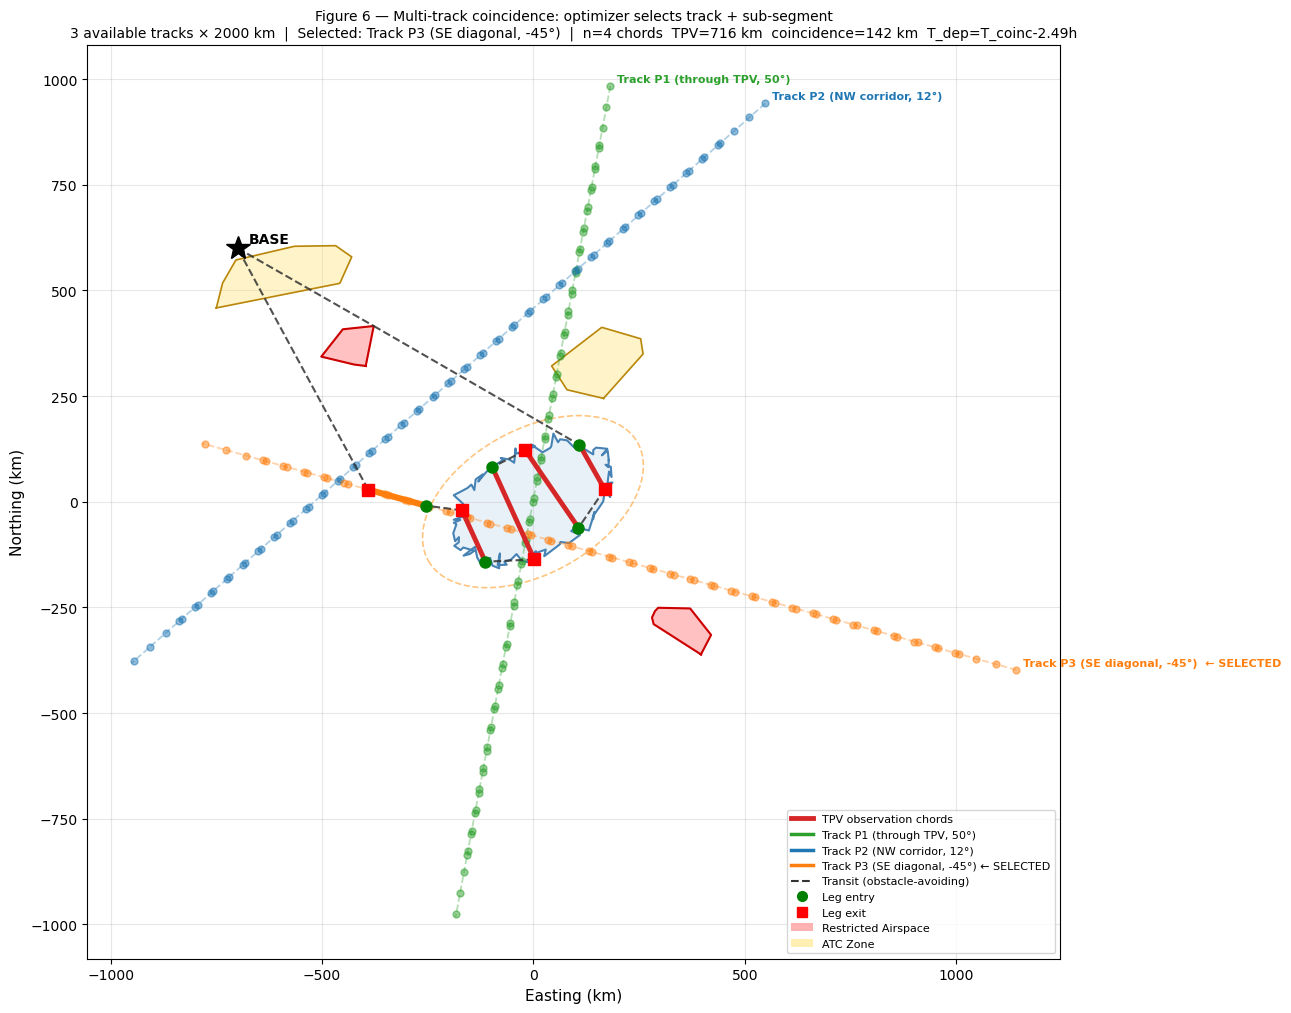

In [14]:
# ── Figure 6: Multi-track coincidence — optimizer selects best track + sub-segment ──
fig, ax = plt.subplots(figsize=(13, 13))

# TPV polygon
closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5, zorder=2)
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.2, alpha=0.5, zorder=3)

# Obstacles
for poly in atc_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ffe066', alpha=0.35, zorder=4)
    ax.plot(xs, ys, color='#b8860b', lw=1.2, zorder=5)
for poly in restricted_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ff6666', alpha=0.40, zorder=6)
    ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)

# All 3 coincidence tracks (faint dashed)
for tr_idx, tr in enumerate(coinc_track_defs):
    col = TRACK_COLORS[tr_idx]
    lc  = np.array(tr['line'].coords)
    ax.plot(lc[:,0], lc[:,1], '--', color=col, lw=1.3, alpha=0.35, zorder=8)
    # Sample points as small dots
    for pt in tr['sample_pts']:
        ax.plot(*pt, 'o', color=col, ms=5, alpha=0.5, zorder=9)
    # Label at far end of track
    far_end = lc[-1] if lc[-1][0] > lc[0][0] else lc[0]
    chosen_marker = '  ← SELECTED' if tr_idx == chosen_tr else ''
    ax.annotate(tr['label'] + chosen_marker,
                xy=far_end, fontsize=8, color=col, fontweight='bold',
                textcoords='offset points', xytext=(5, 3))

# Best route
if best_r_b:
    wpts = best_r_b['waypoints']
    segs = best_r_b['seg_types']
    col_coinc = TRACK_COLORS[chosen_tr]
    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color='#d62728',
                    lw=3.5, zorder=11, solid_capstyle='round')
        elif seg_type == 'sat':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color=col_coinc,
                    lw=4.5, zorder=11, solid_capstyle='round')
        else:
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '--', color='#333333',
                    lw=1.5, zorder=10, alpha=0.85)
    for i, s in enumerate(segs):
        if s in ('tpv', 'sat'):
            ax.plot(*wpts[i],   'o', color='green', ms=8, zorder=12)
            ax.plot(*wpts[i+1], 's', color='red',   ms=8, zorder=12)

ax.plot(*BASE, '*', color='black', ms=18, zorder=13)
ax.annotate('BASE', BASE, textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')
ax.set_aspect('equal')
ax.set_xlabel('Easting (km)', fontsize=11)
ax.set_ylabel('Northing (km)', fontsize=11)
ax.grid(True, alpha=0.3)

# Title
if best_r_b:
    offset = best_r_b['T_dep_h'] - T_SAT_H
    sign   = '+' if offset >= 0 else ''
    ax.set_title(
        f'Figure 6 — Multi-track coincidence: optimizer selects track + sub-segment\n'
        f'3 available tracks × {SAT_TRACK_KM_B:.0f} km  |  '
        f'Selected: {coinc_track_defs[chosen_tr]["label"]}  |  '
        f'n={best_n_b} chords  TPV={best_r_b["tpv_dist"]:.0f} km  '
        f'coincidence={best_r_b["coinc_dist"]:.0f} km  '
        f'T_dep=T_coinc{sign}{offset:.2f}h',
        fontsize=10)

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
leg_elems = [
    Line2D([0],[0], color='#d62728', lw=3.5, label='TPV observation chords'),
    *[Line2D([0],[0], color=TRACK_COLORS[i], lw=2.5,
              label=coinc_track_defs[i]['label']
                    + (' ← SELECTED' if i == chosen_tr else ''))
      for i in range(len(coinc_track_defs))],
    Line2D([0],[0], color='#333333', lw=1.5, ls='--', label='Transit (obstacle-avoiding)'),
    Line2D([0],[0], marker='o', color='green', ms=7, ls='none', label='Leg entry'),
    Line2D([0],[0], marker='s', color='red',   ms=7, ls='none', label='Leg exit'),
    Patch(facecolor='#ff6666', alpha=0.5, label='Restricted Airspace'),
    Patch(facecolor='#ffe066', alpha=0.5, label='ATC Zone'),
]
ax.legend(handles=leg_elems, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()